In [2]:
import pandas as pd
import json

from PIL import Image

In [3]:
with open("/Users/chanha/Projects/bird-diffusion/data/raw/val.json", "r") as f:
    data = json.loads(f.read())

In [12]:
cols = ("id_x", "kingdom", "phylum", "class", "order", "family", "genus", "species")
def parse_fname(name: str) -> dict:
    info = name.split("/")[1].split("_")
    d = {}
    for (col, i) in zip(cols, info):
        d[col] = i
    d["genus_species"] = "_".join(info[-2:])
    return d

df = pd.DataFrame.from_records(data["images"])
df = pd.concat([df, pd.DataFrame.from_records(df.file_name.apply(parse_fname))], axis=1)
birds = df[df["class"] == "Aves"]
birds

,id,width,height,file_name,license,rights_holder,date,latitude,longitude,location_uncertainty,id_x,kingdom,phylum,class,order,family,genus,species,genus_species
0,2686843,284,222,val/03938_Animalia_Chordata_Aves_Passeriformes...,2,megatherium,2007-10-31 00:00:00+00:00,-21.93073,114.12239,NaN,03938,Animalia,Chordata,Aves,Passeriformes,Meliphagidae,Ptilotula,penicillata,Ptilotula_penicillata
1,2686844,500,375,val/03583_Animalia_Chordata_Aves_Cuculiformes_...,1,rpayne,2011-07-15 00:00:00+00:00,44.02901,-73.17711,NaN,03583,Animalia,Chordata,Aves,Cuculiformes,Cuculidae,Coccyzus,erythropthalmus,Coccyzus_erythropthalmus
3,2686846,500,326,val/04487_Animalia_Chordata_Aves_Procellariifo...,1,kestrel,2008-09-20 00:00:00+00:00,40.77782,-124.57932,10000.0,04487,Animalia,Chordata,Aves,Procellariiformes,Diomedeidae,Phoebastria,nigripes,Phoebastria_nigripes
5,2686848,400,500,val/03253_Animalia_Chordata_Aves_Anseriformes_...,2,joecf,2012-01-02 00:00:00+00:00,40.93109,-111.94939,NaN,03253,Animalia,Chordata,Aves,Anseriformes,Anatidae,Mareca,americana,Mareca_americana
11,2686854,494,395,val/03512_Animalia_Chordata_Aves_Columbiformes...,2,megatherium,2007-12-05 00:00:00+00:00,-10.44753,105.69045,NaN,03512,Animalia,Chordata,Aves,Columbiformes,Columbidae,Chalcophaps,indica,Chalcophaps_indica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99987,2786830,500,332,val/04530_Animalia_Chordata_Aves_Psittaciforme...,1,Dirk HR Spennemann,2009-05-20 01:50:00+00:00,-36.03775,146.99132,22.0,04530,Animalia,Chordata,Aves,Psittaciformes,Psittaculidae,Psephotus,haematonotus,Psephotus_haematonotus
99988,2786831,500,408,val/03425_Animalia_Chordata_Aves_Charadriiform...,1,tjeales,2017-07-06 03:35:00+00:00,-42.08111,148.23315,12821.0,03425,Animalia,Chordata,Aves,Charadriiformes,Laridae,Larus,pacificus,Larus_pacificus
99994,2786837,500,375,val/03906_Animalia_Chordata_Aves_Passeriformes...,1,Hans Holbrook,2005-03-12 00:00:00+00:00,38.85476,-76.12688,738.0,03906,Animalia,Chordata,Aves,Passeriformes,Laniidae,Lanius,borealis,Lanius_borealis
99998,2786841,500,333,val/03228_Animalia_Chordata_Aves_Anseriformes_...,1,Joe Bourget,2014-03-03 16:39:00+00:00,42.13839,-71.58764,27692.0,03228,Animalia,Chordata,Aves,Anseriformes,Anatidae,Branta,leucopsis,Branta_leucopsis


In [5]:
birds.file_name[0]

'val/03938_Animalia_Chordata_Aves_Passeriformes_Meliphagidae_Ptilotula_penicillata/df8edd4c-fbb4-4886-8600-a429e5efac23.jpg'

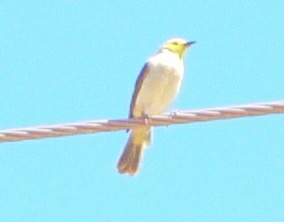

In [6]:
Image.open('../data/raw/val/03938_Animalia_Chordata_Aves_Passeriformes_Meliphagidae_Ptilotula_penicillata/df8edd4c-fbb4-4886-8600-a429e5efac23.jpg')

In [19]:
import os
import shutil

In [21]:
for idx, row in birds.iterrows():
    print(idx, row.file_name, row.genus_species)
    os.makedirs(f"../data/birds/images/{row.genus_species}/", exist_ok=True)
    shutil.copy(f"../data/raw/{row.file_name}", f"../data/birds/images/{row.genus_species}/{os.path.basename(row.file_name)}")

0 val/03938_Animalia_Chordata_Aves_Passeriformes_Meliphagidae_Ptilotula_penicillata/df8edd4c-fbb4-4886-8600-a429e5efac23.jpg Ptilotula_penicillata
1 val/03583_Animalia_Chordata_Aves_Cuculiformes_Cuculidae_Coccyzus_erythropthalmus/fc35080c-5ace-4485-a21f-b1447f27efc7.jpg Coccyzus_erythropthalmus
3 val/04487_Animalia_Chordata_Aves_Procellariiformes_Diomedeidae_Phoebastria_nigripes/5a89f160-b085-4990-a66a-aac18059b7da.jpg Phoebastria_nigripes
5 val/03253_Animalia_Chordata_Aves_Anseriformes_Anatidae_Mareca_americana/d5359888-d956-46a0-9dfb-87099ee1e6dc.jpg Mareca_americana
11 val/03512_Animalia_Chordata_Aves_Columbiformes_Columbidae_Chalcophaps_indica/ab0934dc-1917-45be-a26e-ea312660c0e6.jpg Chalcophaps_indica
13 val/04480_Animalia_Chordata_Aves_Podicipediformes_Podicipedidae_Podilymbus_podiceps/d2d3aa0f-d74c-48e2-9db1-1ff7b902c082.jpg Podilymbus_podiceps
16 val/03275_Animalia_Chordata_Aves_Anseriformes_Anatidae_Tadorna_tadornoides/a0273cc2-51f2-4c1e-bfb0-0f079460431f.jpg Tadorna_tadornoid

In [22]:
from datasets import load_dataset

In [23]:
dataset = load_dataset("../data/birds/images")

Resolving data files:   0%|          | 0/14860 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]